# 전이 학습

## 특성 추출 기법

In [1]:
# OpenCV: Open Source Computer Vision Library
import os
import time
import copy
import glob
import cv2 # opencv
import shutil

import torch
import torchvision
import torchvision.transforms as transforms # 데이터 전처리
import torchvision.models as models # 파이토치 네트워크
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
# 이미지 데이터 전처리 방법 정의
data_path = '/content/drive/MyDrive/Euron Homework/dataset/catanddog/train'

transform = transforms.Compose( # 이미지 데이터 -> 모델 입력으로 사용할 수 있게 변환
    [
        transforms.Resize([256,256]), # 이미지 크기 조정
        transforms.RandomResizedCrop(224), # 이미지를 랜덤 비율로 자른 후 크기 조정(->224x224) (데이터 증강)
        transforms.RandomHorizontalFlip(), # 이미지 랜덤하게 수평으로 뒤집음
        transforms.ToTensor(), # 이미지 데이터 -> 텐서 변환
    ]
)

train_dataset = torchvision.datasets.ImageFolder( # 데이터로더가 데이터 불러올 대상(경로), 방법(transform, 전처리) 정의
    data_path, # 데이터 경로
    transform=transform # 전처리
)
train_loader = torch.utils.data.DataLoader( #ImageFolder(train_dataset) -> 데이터로더 할당
    train_dataset, batch_size=32, num_workers=8, shuffle=True
)
# num_workers: 데이터를 불러올 때 하위 프로세스를 몇 개 사용할지 설정.
## 너무 많은 하위 프로세스를 설정하면 오류가 발생하거나 메모리 부족 현상 발생

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


> **RandomResizedCrop 자세히 알아보기**
* mxnet: 딥러닝 오픈 소스 라이브러리. 파이썬, 줄리아, R, Matlab, Scala 등 다양한 인터페이스 지원, GPU 환경에서 성능 뛰어남

In [ ]:
import numpy as np
if not hasattr(np, 'bool'): # 최신 numpy에 np.bool이 없는 문제 해결
    np.bool = bool

/tmp/ipython-input-1840716378.py:2: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):


In [ ]:
!nvidia-smi
!pip install mxnet

Mon Sep 29 04:19:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

넘파이 버전 호환성 문제 때문에 한 번 오류가 난 뒤 호환되는 넘파이 버전으로 재설치됨

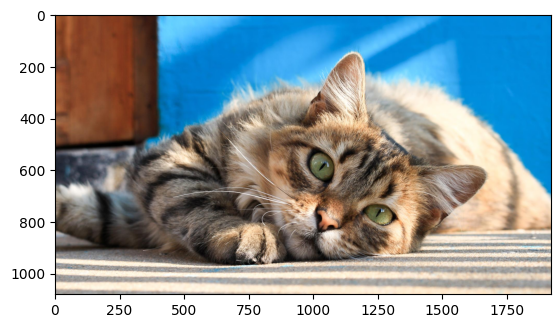

In [ ]:
import matplotlib.pyplot as plt
import mxnet as mx # np.bool 사용되는 버전을 쓰라는 오류
from mxnet.gluon.data.vision import transforms

example_image = mx.image.imread('/content/drive/MyDrive/Euron Homework/dataset/cat.jpg')
plt.imshow(example_image.asnumpy())

In [ ]:
# RandomResizedCrop 적용 함수
def show_images(imgs, num_rows, num_cols, scale=2):
  aspect_ratio=imgs[0].shape[0]/imgs[0].shape[1] # 확장할 이미지의 크기 조정 (가로 세로 비율 맞춘 듯)
  figsize = (num_cols*scale, num_rows*scale*aspect_ratio)
  _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
  for i in range(num_rows):
    for j in range(num_cols):
      axes[i][j].imshow(imgs[i*num_cols+j].asnumpy())
      axes[i][j].axes.get_xaxis().set_visible(False) # x축 숨김
      axes[i][j].axes.get_yaxis().set_visible(False) # y축 숨김
  plt.subplots_adjust(hspace=0.1, wspace=0)
  return axes

def apply(img, aug, num_rows=2, num_cols=4, scale=3):
  Y=[aug(img) for _ in range(num_rows*num_cols)] # 다양한 샘플 얻기 위해 여러 번 데이터 확장 적용
  show_images(Y, num_rows, num_cols, scale)

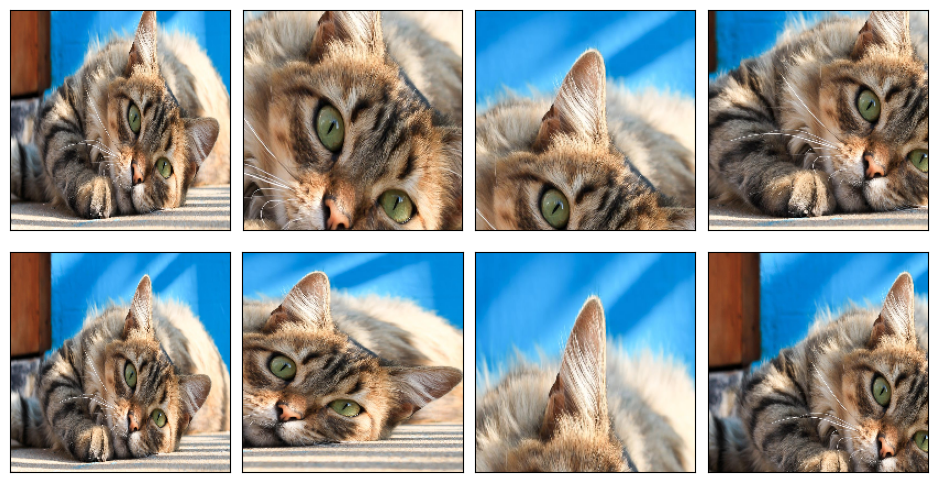

In [ ]:
# RandomResizedCrop 적용 이미지 출력
shape_aug = transforms.RandomResizedCrop(size=(200,200), # 출력 크기 조정
                                         scale=(0.1,1), # 면적 비율을 0.1~1 범위 내에서 무작위로 자름
                                         ratio=(0.5,2)) # 면적의 너비와 높이 비율을 0.5~2 범위 내에서 무작위로 조절
## ratio로 너비 비율 조절 -> scale로 자름 -> size로 조정
apply(example_image, shape_aug)

다시 특성 추출 기법 실습

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


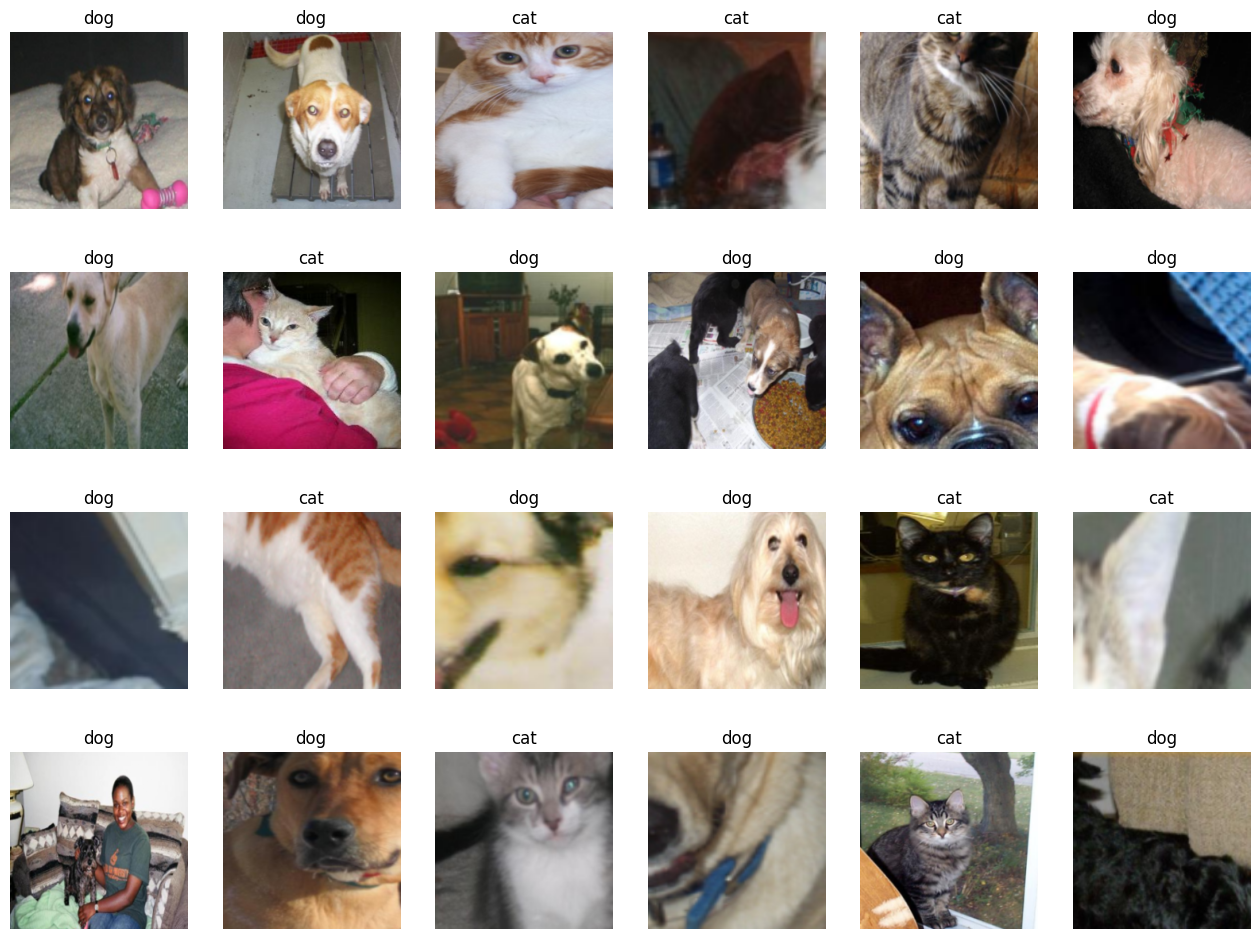

In [4]:
import numpy as np
# 학습에 사용될 이미지 출력
# samples, labels = iter(train_loader).next() # 반복자 효과: iter(), next() 사용 - 옛날 파이썬
samples, labels = next(iter(train_loader))
  ## iter(): 전달된 데이터의 반복자를 꺼내 반환 - 가리키고
  ## next(): 그 반복자가 다음에 출력해야 할 요소 반환 - 꺼내고
  ##     -> train_loader에서 데이터를 하나씩 꺼내옴
classes = {0:'cat', 1:'dog'} # 개와 고양이 클래스로 구성
fig = plt.figure(figsize=(16,24))
for i in range(24): # 이미지 출력
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()]) # 레이블 정보 함께 출력
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0))) # 전치행렬 -> 내적을 위해 차원 조정
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

In [5]:
# 사전 훈련된 모델 내려받기
resnet18 = models.resnet18(pretrained=True) # pretrained=True: 사전 학습된 가중치를 사용하겠다

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


> **ResNet18**: 50개의 계층으로 구성된 합성곱 신경망. ImageNet 데이터베이스의 100만 개가 넘는 영상을 이용해 훈련된 신경망.
입력 제약이 매우 크고, 충분한 RAM이 없으면 학습 속도가 느릴 수 있음

In [6]:
# 사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False # 역전파 중 파라미터들에 대한 변화를 계산할 필요 없음
set_parameter_requires_grad(resnet18)

In [7]:
# ResNet18에 완전연결층 추가
resnet18.fc=nn.Linear(512,2) # 2: 클래스 개수

완전연결층 -> 개와 고양이 클래스 분류하는 용도

In [8]:
# 모델 파라미터 값 확인
for name, param in resnet18.named_parameters(): # model.named_parameters(): 모델 접근해 파라미터 값 가져올 때 사용
  if param.requires_grad:
      print(name, param.data)

fc.weight tensor([[ 0.0283, -0.0137,  0.0372,  ..., -0.0209, -0.0290, -0.0195],
        [ 0.0293,  0.0061,  0.0368,  ..., -0.0335,  0.0285,  0.0422]])
fc.bias tensor([-0.0078,  0.0052])


모델 파라미터로 weight과 bias가 사용되고 있음

In [9]:
# 모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained=True) # 모델 객체 생성 (학습 가중치 사용)
for param in model.parameters(): # 모델의 합성곱층 가중치 고정
  param.requires_grad=False      # 그래디언트 업데이트를 안 하는 것

model.fc = torch.nn.Linear(512,2) # 모델의 fc 객체로 선형 모델을 지정
for param in model.fc.parameters(): # 완전연결층은 학습시킴
  param.requires_grad=True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

-> ResNet18 (사전 학습 모델) + 완전연결층

In [11]:
# 모델 학습을 위한 함수 생성
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since=time.time() # 컴퓨터의 현재 시각
  acc_history=[]
  loss_history=[]
  best_acc=0.0

  for epoch in range(num_epochs): # 13 epoch 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss=0.0
    running_corrects=0

    for inputs, labels in dataloaders: # 데이터로더에 전달된 데이터만큼 반복
      inputs=inputs.to(device)
      labels=labels.to(device) # gpu로

      model.to(device)
      optimizer.zero_grad() # 기울기 0으로 초기화
      outputs = model(inputs) # 순전파 학습
      loss = criterion(outputs, labels)
      _, preds=torch.max(outputs, 1)
      loss.backward() # 역전파 학습
      optimizer.step()

      running_loss +=loss.item() * inputs.size(0) # 출력 결과와 레이블 오차를 계산한 결과를 누적해 저장
      running_corrects += torch.sum(preds==labels.data) # 맞힌 횟수 누적

    epoch_loss = running_loss/len(dataloaders.dataset) # 평균 loss 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 평균 정확도 계산

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('/content/drive/MyDrive/Euron Homework/dataset/catanddog',
                                                '{0:0=2d}.pth'.format(epoch))) # 모델 재사용 위해 저장
    print()

  time_elapsed = time.time() - since # 실행 시간(학습 시간) 계산
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history # 모델 정확도, 오차 반환

In [12]:
# (완전연결층의) 파라미터 학습 결과는 옵티마이저에 전달 -> 최종 모델 학습에 사용
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad==True:
    params_to_update.append(param) # 파라미터 학습 결과 저장
    print("\t", name)

optimizer = optim.Adam(params_to_update) # 학습 결과 옵티마이저에 저장

	 fc.weight
	 fc.bias


weight, bias 값이 업데이트되고 옵티마이저에 전달될 것임

In [13]:
# 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion=nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss: 0.6183 Acc: 0.6364

Epoch 1/12
----------
Loss: 0.4120 Acc: 0.8208

Epoch 2/12
----------
Loss: 0.3408 Acc: 0.8753

Epoch 3/12
----------
Loss: 0.3059 Acc: 0.8727

Epoch 4/12
----------
Loss: 0.3101 Acc: 0.8675

Epoch 5/12
----------
Loss: 0.2122 Acc: 0.9195

Epoch 6/12
----------
Loss: 0.2464 Acc: 0.9091

Epoch 7/12
----------
Loss: 0.2395 Acc: 0.8961

Epoch 8/12
----------
Loss: 0.1845 Acc: 0.9455

Epoch 9/12
----------
Loss: 0.2201 Acc: 0.9065

Epoch 10/12
----------
Loss: 0.2389 Acc: 0.8961

Epoch 11/12
----------
Loss: 0.1918 Acc: 0.9195

Epoch 12/12
----------
Loss: 0.1875 Acc: 0.9273

Training complete in 0m 47s
Best Acc: 0.945455


훈련 데이터에 대한 정확도: 약 0.95 (매우 잘 됨)

In [15]:
# 테스트 데이터 호출 및 전처리
test_path = '/content/drive/MyDrive/Euron Homework/dataset/catanddog/test'
transform = transforms.Compose(
    [
        transforms.Resize(224), # 이미지 크기 조정
        transforms.CenterCrop(224),
        transforms.ToTensor(), # 이미지 데이터 -> 텐서 변환
    ]
)
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


테스트용 데이터로 충분한 양은 아님

In [20]:
# 테스트 데이터 평가 함수
def eval_model(model, dataloaders, device):
  since=time.time() # 컴퓨터의 현재 시각
  acc_history=[]
  best_acc=0.0

  saved_models = glob.glob('/content/drive/MyDrive/Euron Homework/dataset/catanddog/'+'*.pth')
  # glob: 현재 디렉터리에서 원하는 파일만 추출하여 가져올 때 사용 (os 내용에 있었나)
  ## 해당 경로의 pth 확장자를 갖는 파일을 가져오라는 의미
  ## pth 파일: 훈련 데이터로 모델 훈련시킬 때 생성된 파일
  saved_models.sort() # 정렬
  print('saved_model', saved_models)

  for model_path in saved_models: # 저장했던 학습된 모델 사용
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path)) # 학습된 모델 파라미터 불러옴
    model.eval()
    model.to(device)
    running_corrects=0

    for inputs, labels in dataloaders: # 테스트 반복
      inputs=inputs.to(device)
      labels=labels.to(device) # gpu로

      with torch.no_grad(): # autograd 미사용
        outputs = model(inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds=torch.max(outputs.data, 1) # torch.max: 주어진 텐서 배열의 최댓값이 들어있는 인덱스 반환
      preds[preds >= 0.5]=1 # 0.5보다 크면 정답
      preds[preds<0.5]= 0 # 작으면 오답

      # running_corrects += preds.eq(labels.cpu()).int().sum()
      running_corrects += preds.eq(labels).int().sum()
      # pres.eq(labels) preds 배열과 labels가 일치하는지 검사하는 용도
      ## .cpu(): 비교를 위해서는 cpu나 gpu 둘 중 하나에 있어야 함 -> 같은 장치에 옮겨주는 것

    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 테스트 데이터 정확도 계산
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    print()

  time_elapsed = time.time() - since # 실행 시간(학습 시간) 계산
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history # 정확도 반환

In [23]:
# 테스트 데이터 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/drive/MyDrive/Euron Homework/dataset/catanddog/00.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/01.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/02.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/03.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/04.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/05.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/06.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/07.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/08.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/09.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/10.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/11.pth', '/content/drive/MyDrive/Euron Homework/dataset/catanddog/12.pth']
Loading model /content/drive/MyDrive/Euron Homework/dataset/catanddog/00.pth
Acc: 0.7959

Loading model /content/drive/MyDrive/Eu

테스트 데이터 정확도: 약 0.97

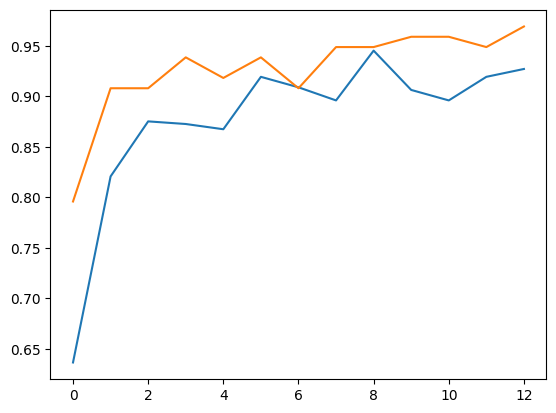

In [24]:
# 훈련과 테스트 데이터 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

epoch가 진행됨에 따라 정확도가 1에 가까워지고 있음

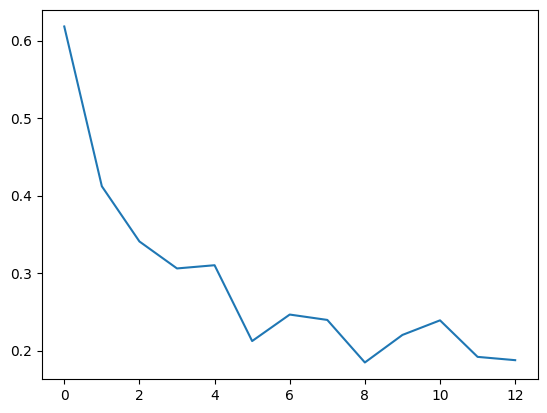

In [25]:
# 훈련 데이터 loss 그래프
plt.plot(train_loss_hist)
plt.show()

In [29]:
# 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image = tensor.clone().detach().numpy()
  # tensor.clone(): 기존 텐서의 내용을 복사한 텐서 생성
  # detach(): 기존 텐서에서 기울기가 전파되지 않는 텐서 -> 복사만 하고 기울기에 영향을 주지 X
  image = image.transpose(1,2,0)
  image = image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
  image = image.clip(0,1) # 입력 값을 특정 범위로 제한시킴
  return image

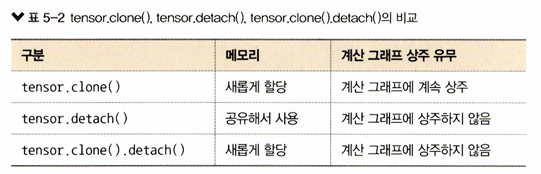

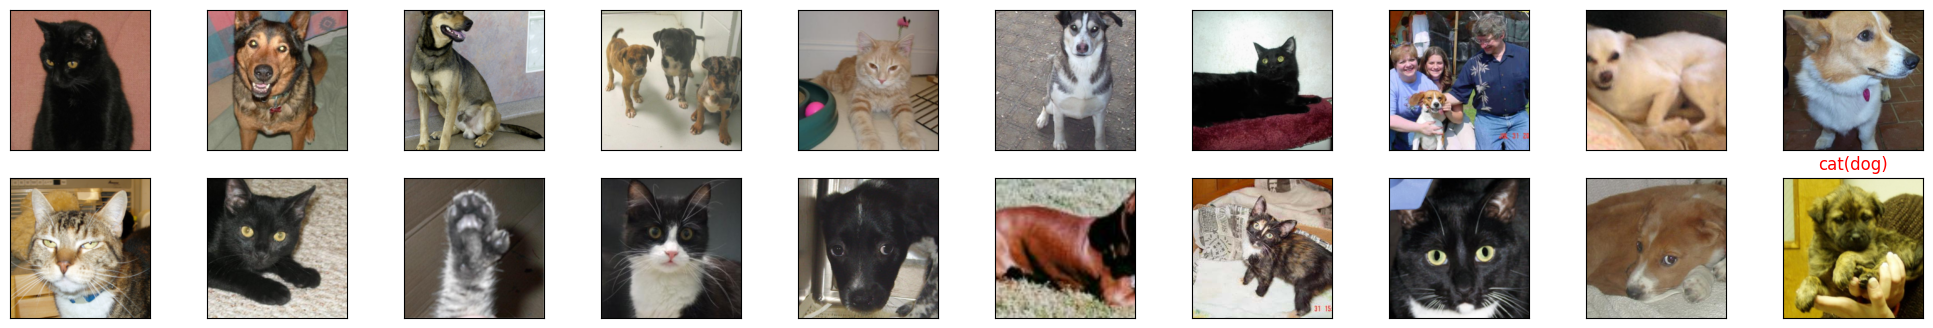

<Figure size 640x480 with 0 Axes>

In [30]:
# 개와 고양이 예측 결과 출력
classes = {0:'cat', 1:'dog'} # 개와 고양이 두 개에 대한 레이블

images, labels = next(iter(test_loader)) # 테스트 데이터셋의 이미지, 레이블 가져옴
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig.add_subplot(2,10,idx+1,xticks=[], yticks=[]) # 한 화면에 여러 이미지 담음
  ## 파라미터: 행의 수, 열의 수, 인덱스, 틱(축) 삭제
  plt.imshow(im_convert(images[idx])) # 이미지 출력 함수 호출
  a.set_title(classes[labels[i].item()])
ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
             color=("green" if preds[idx]==labels[idx] else "red"))
# classes[preds[idx].item()]: pred[idx].item() 값이 어떤 값을 갖는지 판별
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0) # subplot 조정

# 설명 가능한 CNN

## 특성 맵 시각화

In [33]:
# 라이브러리 호출
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [35]:
# 설명 가능한 네트워크 생성
## 13개 합성곱층 + 2개 완전연결층 (ReLU 사용)
class XAI(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(XAI, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Conv2d(64, 64, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(128, 128, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 512, bias=False),
            nn.Dropout(0.5),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 512)
        x = self.classifier(x)
        return F.log_softmax(x)
# log_softmax: 신경망 말단 결괏값들을 확률 개념으로 해석하기 위해 소프트맥스 함수 결과에 log 값 취한 연산
## softmax는 기울기 소멸 문제에 취약함

In [55]:
# 모델 객체화 후 장치 할당
model = XAI() # model이라는 이름의 **객체** 생성
# model.to(device) # gpu 텐서 -> numpy 안 돼서 모델과 img 둘 다 cpu에 넣음
model.eval() # 테스트 데이터에 대한 모델 평가 용도로 사용

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

특성 맵: 합성곱층 - 입력 이미지와 필터를 연산하여 얻은 결과

-> 합성곱층의 입력과 출력을 확인해 특성 맵에 대한 값들을 확인하면 됨

In [56]:
# (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)에 대한
## 특성 맵을 확인하기 위한 클래스 정의
class LayerActivations:
    features=[]
    def __init__(self, model, layer_num):
        self.hook = model[layer_num].register_forward_hook(self.hook_fn)
        # 파이토치에서는 hook 기능을 통해 각 계층의 활성화 함수 및 기울기 값 확인 가능
        ## register_forward_hook: 순전파 중 각 네트워크 모듈의 입력 및 출력을 가져옴 -- 중간 결과값들 확인 가능!

    def hook_fn(self, module, input, output):
        output = output
        self.features = output.detach().numpy() # gpu에 있는 텐서는 바로 numpy로 변환할 수 없다는 오류가 뜸
    def remove(self):
        self.hook.remove()

torch.Size([1, 3, 100, 100])


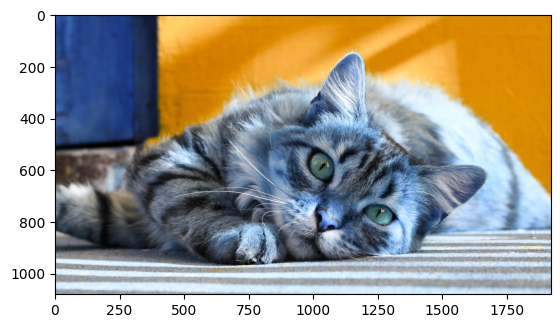

In [57]:
# 이미지 호출
img=cv2.imread("/content/drive/MyDrive/Euron Homework/dataset/cat.jpg")
plt.imshow(img)
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR) # 이미지 크기 변경
## 파라미터: 변경할 이미지 파일, 크기, interpolation
## 보간법(interpolation): 이미지상 존재하는 픽셀 데이터 (xi, yi) 들에 대해
### 근사 함수 f(x,y)를 적용해 새로운 픽셀 값을 구하는 것
### (이미지 크기를 변형하면 변형된 이미지의 픽셀 값을 추정해 값을 할당해야 함)
img = ToTensor()(img).unsqueeze(0) # unsqueeze(): 1차원 데이터 새엇ㅇ 함수

print(img.shape)

색이 왜 다르지?

In [58]:
# (0): Conv2d 특성 맵 확인
result = LayerActivations(model.features, 0)

model(img)
activations = result.features

/tmp/ipython-input-1503018603.py:77: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


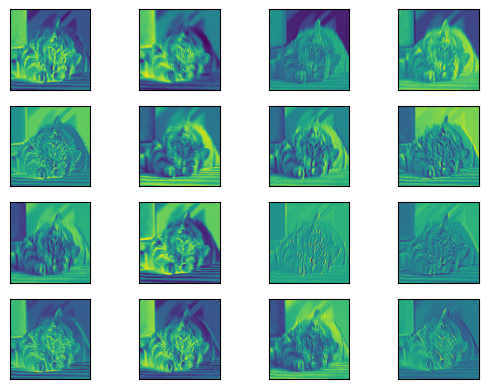

<Figure size 1200x800 with 0 Axes>

In [59]:
# 특성 맵 확인
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

위 결과가 첫 번째 Conv2d 계층 feature map에 대한 출력 결과. 입력층과 가까운 계층이므로 입력 이미지의 형태가 많이 유지됨.

In [60]:
# 20번째 계층 특성 맵
result = LayerActivations(model.features, 20)

model(img)
activations = result.features

/tmp/ipython-input-1503018603.py:77: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


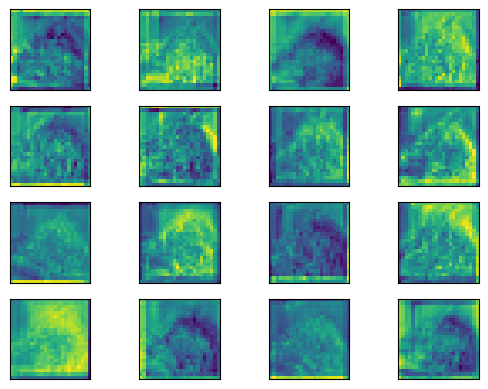

<Figure size 1200x800 with 0 Axes>

In [61]:
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

In [62]:
# 40번째 계층 특성 맵
result = LayerActivations(model.features, 40)

model(img)
activations = result.features

/tmp/ipython-input-1503018603.py:77: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


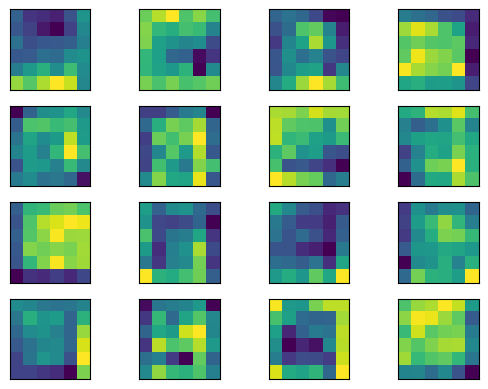

<Figure size 1200x800 with 0 Axes>

In [63]:
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

1 -> 20 -> 40 번째 계층으로 갈수록 입력 이미지의 고양이 형태를 찾아볼 수 없게 됨. 즉 출력층에 가까울수록 원래 형태는 찾아보기 힘들고, 이미지의 특징들만 전달된다는 것을 알 수 있음.